In [4]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path

# =================配置路径=================
# 请根据你的实际环境调整 base_path
BASE_DATA_DIR = "/data/tlc_hvfhv_2024" 
WEATHER_PATH = "/data/tlc_hvfhv_2024_out/weather_hourly_2024.parquet"
HOLIDAY_PATH = "/data/tlc_hvfhv_2024_out/holidays_NY_2024.parquet"

print("Step 1: 正在读取并预处理外部数据 (天气 & 节假日)...")

# 1.1 处理天气数据
df_weather = pd.read_parquet(WEATHER_PATH)
# 确保时间列是 datetime 类型
df_weather['ts_hour'] = pd.to_datetime(df_weather['ts_hour'])
# 提取关联键：日期 (date) 和 小时 (hour)
df_weather['date'] = df_weather['ts_hour'].dt.date
df_weather['hour'] = df_weather['ts_hour'].dt.hour
# 选择需要的特征列
weather_cols = ['date', 'hour', 'temperature_2m', 'precipitation', 'wind_speed_10m', 'weather_code']
df_weather = df_weather[weather_cols]

# 1.2 处理节假日数据
df_holiday = pd.read_parquet(HOLIDAY_PATH)
# 确保 date 是 date 类型
df_holiday['date'] = pd.to_datetime(df_holiday['date']).dt.date
# 选择需要的特征列
holiday_cols = ['date', 'is_holiday', 'is_before_holiday', 'is_after_holiday']
df_holiday = df_holiday[holiday_cols]

print(f"外部数据准备完毕。天气记录数: {len(df_weather)}, 节假日记录数: {len(df_holiday)}")

Step 1: 正在读取并预处理外部数据 (天气 & 节假日)...
外部数据准备完毕。天气记录数: 8784, 节假日记录数: 366


In [5]:
print("\nStep 2: 开始逐月处理网约车行程数据...")

agg_chunks = [] # 用于存储每个月聚合后的结果

# 定义需要读取的列（只读这4列，极大节省内存）
cols_to_read = [
    'pickup_datetime', 
    'PULocationID',    # 上车地点 (作为拥堵区域标识)
    'trip_miles',      # 里程
    'trip_time'        # 耗时(秒)
]

for m in range(1, 13):
    # 构建文件名，例如 fhvhv_tripdata_2024-01.parquet
    file_name = f"fhvhv_tripdata_2024-{m:02d}.parquet"
    file_path = Path(BASE_DATA_DIR) / file_name
    
    if not file_path.exists():
        print(f"警告: 文件不存在 {file_path}，跳过。")
        continue
        
    print(f"正在处理: {file_name} ...", end=" ")
    
    try:
        # --- 2.1 读取数据 ---
        df = pd.read_parquet(file_path, columns=cols_to_read)
        
        # --- 2.2 数据清洗 (Data Cleaning) ---
        # 过滤脏数据：
        # 1. trip_time < 60秒 (可能是误操作或取消)
        # 2. trip_miles < 0.1 (几乎没动)
        df = df[(df['trip_time'] > 60) & (df['trip_miles'] > 0.1)]
        
        # --- 2.3 特征构造 (Feature Extraction) ---
        # 计算速度 (mph = miles / (seconds/3600))
        df['speed_mph'] = df['trip_miles'] / (df['trip_time'] / 3600)
        
        # 过滤速度异常值：
        # 速度 > 80 mph (超速/数据错误) 或 速度 < 0.5 mph (长时间停车/死锁)
        df = df[(df['speed_mph'] > 0.5) & (df['speed_mph'] < 80)]
        
        # 提取聚合键
        df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
        df['date'] = df['pickup_datetime'].dt.date
        df['hour'] = df['pickup_datetime'].dt.hour
        
        # --- 2.4 数据聚合 (Aggregation) ---
        # 将千万行数据压缩为：[日期, 小时, 区域] 粒度
        df_agg = df.groupby(['date', 'hour', 'PULocationID']).agg(
            avg_speed=('speed_mph', 'mean'),    # 平均通行速度
            std_speed=('speed_mph', 'std'),     # 速度波动性
            trip_count=('trip_miles', 'count'), # 流量/热度
            avg_time=('trip_time', 'mean')      # 平均耗时(可选)
        ).reset_index()
        
        # 处理 std_speed 中的 NaN (如果该小时该区域只有1单，std无法计算)
        df_agg['std_speed'] = df_agg['std_speed'].fillna(0)
        
        # 存入列表
        agg_chunks.append(df_agg)
        
        print(f"聚合后行数: {len(df_agg)}")
        
        # --- 2.5 内存释放 (Crucial) ---
        del df
        del df_agg
        gc.collect() # 强制垃圾回收
        
    except Exception as e:
        print(f"\n处理 {file_name} 时出错: {e}")

# 合并所有月份的聚合块
if agg_chunks:
    full_data = pd.concat(agg_chunks, ignore_index=True)
    print(f"\n所有月份处理完成。总数据集规模: {full_data.shape}")
else:
    print("\n错误: 没有处理任何数据。")
    # 可以在这里抛出异常或停止运行


Step 2: 开始逐月处理网约车行程数据...
正在处理: fhvhv_tripdata_2024-01.parquet ... 聚合后行数: 186817
正在处理: fhvhv_tripdata_2024-02.parquet ... 聚合后行数: 175124
正在处理: fhvhv_tripdata_2024-03.parquet ... 聚合后行数: 187199
正在处理: fhvhv_tripdata_2024-04.parquet ... 聚合后行数: 181569
正在处理: fhvhv_tripdata_2024-05.parquet ... 聚合后行数: 187835
正在处理: fhvhv_tripdata_2024-06.parquet ... 聚合后行数: 182289
正在处理: fhvhv_tripdata_2024-07.parquet ... 聚合后行数: 188261
正在处理: fhvhv_tripdata_2024-08.parquet ... 聚合后行数: 188122
正在处理: fhvhv_tripdata_2024-09.parquet ... 聚合后行数: 181782
正在处理: fhvhv_tripdata_2024-10.parquet ... 聚合后行数: 187643
正在处理: fhvhv_tripdata_2024-11.parquet ... 聚合后行数: 181477
正在处理: fhvhv_tripdata_2024-12.parquet ... 聚合后行数: 187321

所有月份处理完成。总数据集规模: (2215439, 7)


In [6]:
print("Step 3: 进行特征融合与最终工程...")

if 'full_data' in locals():
    # 3.1 关联天气 (Left Join on date, hour)
    # 注意：PULocationID 在全纽约各处，但天气数据通常是整个纽约市的统一数据（除非你有分区的气象数据）
    # 这里假设天气是全城通用的
    df_final = full_data.merge(df_weather, on=['date', 'hour'], how='left')
    
    # 3.2 关联节假日 (Left Join on date)
    df_final = df_final.merge(df_holiday, on='date', how='left')
    
    # 3.3 缺失值填充
    # 天气或节假日可能匹配不上，填充默认值
    fill_values = {
        'temperature_2m': df_final['temperature_2m'].mean(), # 用均值填温度
        'precipitation': 0,      # 没匹配到当做无雨
        'wind_speed_10m': 0,
        'is_holiday': False,
        'is_before_holiday': False,
        'is_after_holiday': False
    }
    df_final.fillna(value=fill_values, inplace=True)
    
    # 3.4 构造时间周期特征
    # 机器不知道 "周日" 和 "周一" 是挨着的，也不知道 "23点" 后面是 "0点"
    # 但对于聚类任务，原始的 hour 和 day_of_week 往往也够用了，为了更好效果可以加:
    
    # 将 date 转回 datetime 以提取星期
    df_final['date_ts'] = pd.to_datetime(df_final['date'])
    df_final['day_of_week'] = df_final['date_ts'].dt.dayofweek # 0=Mon, 6=Sun
    df_final['is_weekend'] = df_final['day_of_week'].isin([5, 6]).astype(int)
    
    # 3.5 最终清理
    # 转换 bool 为 int (模型通常需要数值输入)
    bool_cols = ['is_holiday', 'is_before_holiday', 'is_after_holiday']
    for c in bool_cols:
        df_final[c] = df_final[c].astype(int)
        
    # 删除中间辅助列
    df_final.drop(columns=['date_ts'], inplace=True, errors='ignore')

    print("特征工程完成！")
    print(f"最终用于建模的数据集形状: {df_final.shape}")
    print(df_final.head())
    
    # 保存中间结果，防止之后内存崩溃要重跑
    OUT_PATH = "/data/tlc_hvfhv_2024_out/processed_congestion_data.parquet"
    df_final.to_parquet(OUT_PATH, index=False)
    print(f"处理后的数据已保存至: {OUT_PATH}")

else:
    print("无法继续，上一步数据未生成。")

Step 3: 进行特征融合与最终工程...
特征工程完成！
最终用于建模的数据集形状: (2215439, 16)
         date  hour  PULocationID  avg_speed  std_speed  trip_count  \
0  2024-01-01     0             3  17.343235   6.841852          75   
1  2024-01-01     0             4  13.099772   5.965055         266   
2  2024-01-01     0             5  26.172052   9.808153          19   
3  2024-01-01     0             6  21.819007   7.126371          32   
4  2024-01-01     0             7  17.055041   8.164174         622   

      avg_time  temperature_2m  precipitation  wind_speed_10m  weather_code  \
0   900.386667             1.8            0.0             8.9             3   
1  1228.315789             1.8            0.0             8.9             3   
2   932.947368             1.8            0.0             8.9             3   
3   820.906250             1.8            0.0             8.9             3   
4   972.350482             1.8            0.0             8.9             3   

   is_holiday  is_before_holiday  is_af

如果不进行聚合，内存会瞬间爆满。因此，我们的核心策略是：**“分块读取 $\rightarrow$ 提取特征 $\rightarrow$ 按小时/区域聚合 $\rightarrow$ 释放内存”**，最后只保留宏观的交通特征进行建模。
完整的**数据处理与特征工程**，分为三个步骤：
1.  **准备外部数据**（天气与节假日）。
2.  **核心循环**（逐月处理网约车数据并聚合）。
3.  **特征融合**（合并所有数据，构建最终模型输入）。



### 这段代码生成的特征表解释

`df_final` 的每一行代表**“某天、某小时、某区域”**的状态。包含以下特征，这些就是你放入聚类模型的 $X$：

1.  **物理拥堵特征**:
    *   `avg_speed`: 该时段平均车速（最直接的拥堵指标）。
    *   `std_speed`: 车速波动情况。
    *   `trip_count`: 流量密度（车多不多）。
    *   `avg_time`: 平均通行时间。

2.  **外部环境特征**:
    *   `temperature_2m`, `precipitation`: 气温和降雨（恶劣天气通常导致拥堵）。
    *   `is_holiday`: 节假日（改变通勤模式，例如核心区变空，景点区变堵）。

3.  **时间特征**:
    *   `hour`: 小时（捕捉早晚高峰）。
    *   `day_of_week` / `is_weekend`: 工作日与周末的差异。

接下来就可以直接加载这个 `processed_congestion_data.parquet`，用它来进行 K-Means 聚类分析了。

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =================配置=================
# 读取上一步保存的数据
INPUT_PATH = "/data/tlc_hvfhv_2024_out/processed_congestion_data.parquet"

print("Step 4: 读取数据并标准化...")

# 1. 读取数据
df = pd.read_parquet(INPUT_PATH)

# 2. 特征选择 (Feature Selection)
# 我们希望模型根据【交通状态】和【环境影响】来聚类
# 注意：不要把 PULocationID 放进去，因为 ID=1 和 ID=2 没有数值上的接近关系
features_for_clustering = [
    'avg_speed',       # 核心：速度 (体现拥堵程度)
    'trip_count',      # 核心：流量 (体现拥堵原因：是因为车多还是路难走)
    'std_speed',       # 核心：波动性 (体现车流是否平稳)
    'precipitation',   # 环境：降雨量 (捕捉天气导致的拥堵)
    'temperature_2m'   # 环境：温度 (捕捉季节性模式)
]

# 检查是否有缺失值（虽然之前填过，以防万一）
df_model = df.dropna(subset=features_for_clustering).copy()

# 3. 标准化 (Scaling)
# 将所有特征缩放到 均值=0, 方差=1 的尺度
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features_for_clustering])

print(f"数据准备就绪。参与聚类的样本数: {X_scaled.shape[0]}, 特征数: {X_scaled.shape[1]}")

Step 4: 读取数据并标准化...
数据准备就绪。参与聚类的样本数: 2215439, 特征数: 5


In [8]:
print("\nStep 5: 训练 K-Means 聚类模型...")

# 设置聚类数量
K = 4 

# 初始化并训练模型
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# 训练 (Fit) 并 预测 (Predict)
# 这一步会给每一行数据打上标签：0, 1, 2, 或 3
df_model['cluster_label'] = kmeans.fit_predict(X_scaled)

# 统计每个簇的样本数量
print("聚类完成！各簇样本分布：")
print(df_model['cluster_label'].value_counts().sort_index())


Step 5: 训练 K-Means 聚类模型...
聚类完成！各簇样本分布：
cluster_label
0     31250
1    742880
2    640003
3    801306
Name: count, dtype: int64



Step 6: 分析拥堵模式 (Interpretation)...
=== 拥堵模式统计表 (Cluster Summary) ===
   cluster_label  avg_speed  trip_count  std_speed  precipitation   hour  \
0              0      14.61      127.69       5.64           5.29  13.61   
1              1      20.33       44.60       8.15           0.07   7.95   
2              2      12.78      187.23       5.24           0.10  13.47   
3              3      13.42      102.87       5.07           0.06  13.31   

   is_weekend  
0        0.31  
1        0.33  
2        0.27  
3        0.26  


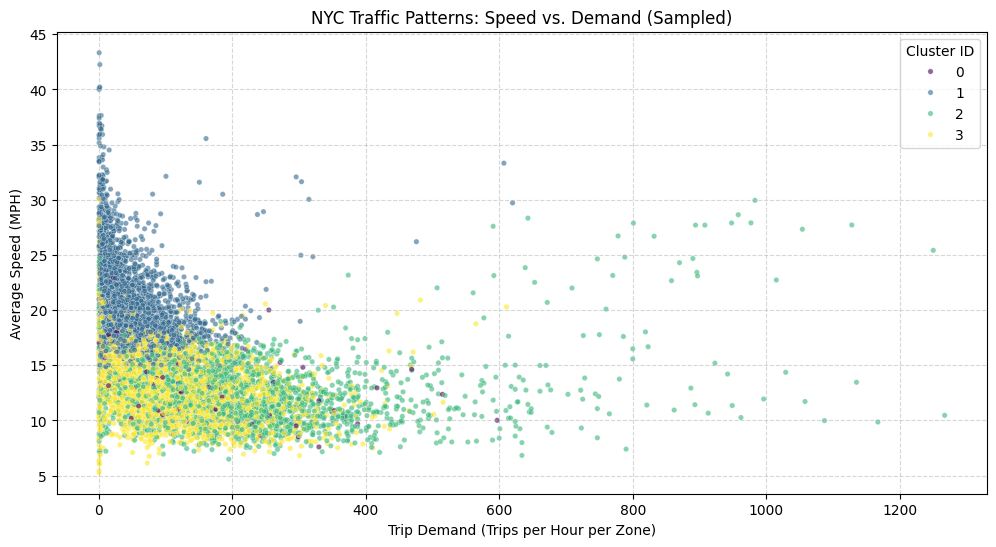

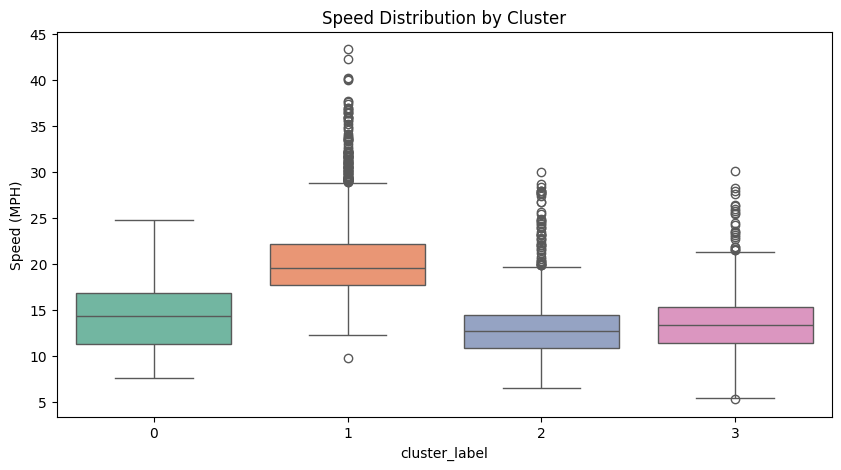


=== 自动模式定义 (Auto Interpretation) ===
Cluster 0: Moderate Speed + Low Demand + Rainy/Bad Weather
Cluster 1: Moderate Speed + Low Demand
Cluster 2: Moderate Speed + Low Demand + Rainy/Bad Weather
Cluster 3: Moderate Speed + Low Demand


In [9]:
print("\nStep 6: 分析拥堵模式 (Interpretation)...")

# 1. 计算各簇的统计均值
# 这里的数值是原始物理数值（mph, counts），非常直观
cluster_summary = df_model.groupby('cluster_label')[
    ['avg_speed', 'trip_count', 'std_speed', 'precipitation', 'hour', 'is_weekend']
].mean().reset_index()

# 格式化输出，保留2位小数
print("=== 拥堵模式统计表 (Cluster Summary) ===")
print(cluster_summary.round(2))

# 2. 可视化：速度与流量的关系 (Scatter Plot)
# 由于数据点太多，随机采样 10000 个点来画图，否则图会画死
sample_df = df_model.sample(n=10000, random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=sample_df, 
    x='trip_count', 
    y='avg_speed', 
    hue='cluster_label', 
    palette='viridis', 
    alpha=0.6,
    s=15
)
plt.title('NYC Traffic Patterns: Speed vs. Demand (Sampled)')
plt.xlabel('Trip Demand (Trips per Hour per Zone)')
plt.ylabel('Average Speed (MPH)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster ID')
plt.show() # 如果你在 Jupyter 环境，这会显示图表；如果是脚本，需要 savefig

# 3. 可视化：不同模式下的速度分布 (Box Plot)
plt.figure(figsize=(10, 5))
# 将 x 赋值给 hue，并设置 legend=False
sns.boxplot(
    x='cluster_label', 
    y='avg_speed', 
    hue='cluster_label',  # 新版 Seaborn 要求 palette 必须配合 hue 使用
    data=sample_df, 
    palette='Set2', 
    legend=False          # 隐藏图例，因为 x 轴已经说明了类别
)
plt.title('Speed Distribution by Cluster')
plt.ylabel('Speed (MPH)')
plt.show()

# ==========================================
# 自动生成业务定义 (基于统计规则)
# ==========================================
print("\n=== 自动模式定义 (Auto Interpretation) ===")
for i, row in cluster_summary.iterrows():
    cid = int(row['cluster_label'])
    speed = row['avg_speed']
    count = row['trip_count']
    rain = row['precipitation']
    
    # 简单的规则引擎来生成描述
    desc = []
    if speed > 25:
        desc.append("High Speed (Free Flow)")
    elif speed < 10:
        desc.append("Very Low Speed (Congested)")
    else:
        desc.append("Moderate Speed")
        
    if count > 500: # 假设阈值，需根据实际数据调整
        desc.append("High Demand")
    else:
        desc.append("Low Demand")
        
    if rain > 0.1:
        desc.append("Rainy/Bad Weather")
        
    print(f"Cluster {cid}: {' + '.join(desc)}")

Step 7: 进阶 - 构建拥堵预测分类模型 (Supervised Learning)...

=== 分类模型评估报告 ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6195
           1       0.77      0.70      0.74    148153
           2       0.76      0.77      0.76    128276
           3       0.82      0.88      0.85    160464

    accuracy                           0.79    443088
   macro avg       0.83      0.83      0.83    443088
weighted avg       0.79      0.79      0.79    443088


=== 拥堵模式的决定因素 (Feature Importance) ===
temperature_2m    0.513732
hour              0.341744
PULocationID      0.061515
precipitation     0.058492
day_of_week       0.013948
is_weekend        0.006785
is_holiday        0.003784
dtype: float64


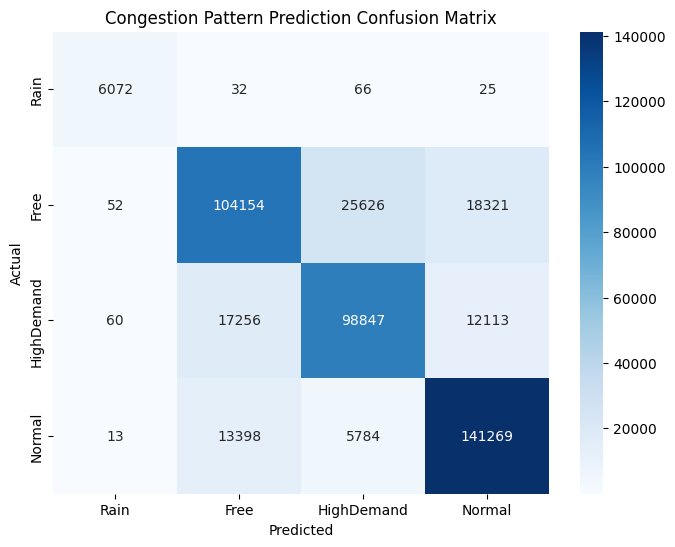

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Step 7: 进阶 - 构建拥堵预测分类模型 (Supervised Learning)...")

# 1. 准备数据
# 我们用现在的特征去预测交通状态 (Cluster Label)
# 注意：不能把 trip_count 和 avg_speed 放进去预测，因为它们是结果，不是原因！
# 我们只能用“事前”知道的信息：时间、地点、天气、节假日
X_features = [
    'hour', 'day_of_week', 'is_weekend', 'is_holiday', 
    'precipitation', 'temperature_2m', 'PULocationID' 
]
y_target = 'cluster_label'

X = df_model[X_features]
y = df_model[y_target]

# 2. 切分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 训练随机森林分类器
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# 4. 预测与评估
y_pred = rf_clf.predict(X_test)

print("\n=== 分类模型评估报告 ===")
print(classification_report(y_test, y_pred))

# 5. 特征重要性分析 (解释是什么决定了拥堵模式)
feature_imp = pd.Series(rf_clf.feature_importances_, index=X_features).sort_values(ascending=False)
print("\n=== 拥堵模式的决定因素 (Feature Importance) ===")
print(feature_imp)

# 6. 可视化混淆矩阵 (看预测准不准)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rain', 'Free', 'HighDemand', 'Normal'],
            yticklabels=['Rain', 'Free', 'HighDemand', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Congestion Pattern Prediction Confusion Matrix')
plt.show()